In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 10 # try 10 just to see covariance matrices
rate = 10 
time = 1000
num_samples = 100 # change to 100 to show Alex next time, but plot the first five trajectories or random five 
t0 = 200

In [4]:
# Simulation control parameters

# Network parameters
N_E = 1000
gamma = 0.25                    # ratio of inhibitory to excitatory neurons
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.5                   # Sparsity of connections.  changed from 0.1, 0.2 was fine...
C_E = epsilon * N_E             # number of excitatory connections per neuron
C_ext = C_E                     # external connections per neuron


# Neuron parameters
tau = 20  * ms                  # Membrane time constant. previously 20, tried 50 it was weird, larger numbers more spikes, smaller numbers less spikes
                                # Higher Tau means slower decay, more spikes.
                                # Lower Tau means faster decay, fewer spikes
theta = 20  * mV                # spike threshold voltage, neuron fires when hitting this value
V_r = 10  * mV                  # reset potential, voltage neuron goes back to after firing
tau_rp = 2  * ms                # refractory period (neuron needs to wait some time before spiking again)

# Synapse parameters
J = 0.1 * mV                    # Synaptic strength # Previously 0.1 * mV, previouysly 0.075, 0.2 was too varied need to be more consistent
                                # larger J, stronger synaptic input, higher firing rate
                                # smaller J, weaker input, lower firing rates
D = 1.5  * ms                   # synaptic delay, time between a pre spike and its effect on postsynap neuron

# Simulation settings
dt = 0.1  * ms
g = 4                           # g is a good control for manipulating the firing rate, smaller numbers more spikes, bigger numbers less spikes
                                # Higher g, stronger inhibition, suppresses network activity
                                # Lower g, weaker inhibition, increase network activity
nu_ext_over_nu_thr = 1          # Previously 2, 1.2 was weird, 1 (made 2d plot nice), 0.5 not good,
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

nu_thr = theta / (J * C_E * tau) # minimal input rate needed to reach threshold
nu_ext = nu_ext_over_nu_thr * nu_thr # external input rate

# adjust g and nu_ext so that nu_ext is approximately the number of spikes that are occuring, influenced by g. 
# epsilon 0.2 and g = 2.6, g = 2.8 is too much,tau = 50
# epsilon 0.5 and g = 4, tau = 20

Generating spike trains, then counting the spikes.

In [6]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
# print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


In [7]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
# print(loaded_spike_trains)

Spike trains saved to spike_trains.json


In [8]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.0877, 0.1498, 0.2821, 0.3057, 0.3691, 0.3738, 0.4095, 0.5655,
       0.7807, 0.8854, 0.901 , 0.9818, 0.9871]), 1: array([0.0567, 0.1513, 0.2639, 0.3241, 0.3409, 0.3913, 0.4136, 0.4848]), 2: array([0.039 , 0.0831, 0.1734, 0.2461, 0.2551, 0.2622, 0.3267, 0.4634,
       0.4891, 0.4971, 0.7283, 0.7961, 0.9532]), 3: array([0.0759, 0.3287, 0.9621]), 4: array([0.1282, 0.19  , 0.4078, 0.7367, 0.8651]), 5: array([0.0513, 0.0639, 0.071 , 0.1673, 0.2034, 0.2195, 0.2636, 0.2637,
       0.2879, 0.5562, 0.5864, 0.8507, 0.9241]), 6: array([0.4273, 0.5967, 0.5995, 0.6003, 0.6073, 0.7701, 0.8248, 0.8371,
       0.91  ]), 7: array([0.0995, 0.1672, 0.213 , 0.2505, 0.4568, 0.8198, 0.9489]), 8: array([0.1681, 0.193 , 0.2476, 0.3302, 0.3409, 0.3944, 0.3989, 0.4372,
       0.4684, 0.752 , 0.9067]), 9: array([0.0825, 0.168 , 0.1936, 0.1954, 0.4457, 0.45  , 0.5158, 0.5203,
       0.6099, 0.6277, 0.691 , 0.7258, 0.8612])}, {0: array([0.1389, 0.1433, 0.1628, 0.4031, 0.4246, 0.5037, 0.5659, 0.6298,


In [9]:
first_spikes = []
for sample in spike_train:
    sample_first_spikes = {}
    for neuron in sample:
        if len(sample[neuron]) > 0:
            sample_first_spikes[neuron] = np.min(sample[neuron])
        else:
            sample_first_spikes[neuron] = None  # Handle case with no spikes
    first_spikes.append(sample_first_spikes)

for i, sample in enumerate(first_spikes):
    print(f"Sample {i}: {sample}")

Sample 0: {0: np.float64(0.0877), 1: np.float64(0.0567), 2: np.float64(0.039), 3: np.float64(0.07590000000000001), 4: np.float64(0.1282), 5: np.float64(0.051300000000000005), 6: np.float64(0.4273), 7: np.float64(0.0995), 8: np.float64(0.1681), 9: np.float64(0.0825)}
Sample 1: {0: np.float64(0.1389), 1: np.float64(0.031), 2: np.float64(0.021500000000000002), 3: np.float64(0.053000000000000005), 4: np.float64(0.1704), 5: np.float64(0.0563), 6: np.float64(0.0109), 7: np.float64(0.028), 8: np.float64(0.0146), 9: np.float64(0.10880000000000001)}
Sample 2: {0: np.float64(0.015600000000000001), 1: np.float64(0.0216), 2: np.float64(0.0454), 3: np.float64(0.0507), 4: np.float64(0.0397), 5: np.float64(0.029400000000000003), 6: np.float64(0.060700000000000004), 7: np.float64(0.23770000000000002), 8: np.float64(0.0823), 9: np.float64(0.4924)}
Sample 3: {0: np.float64(0.0755), 1: np.float64(0.10600000000000001), 2: np.float64(0.09960000000000001), 3: np.float64(0.0539), 4: np.float64(0.0845), 5: np

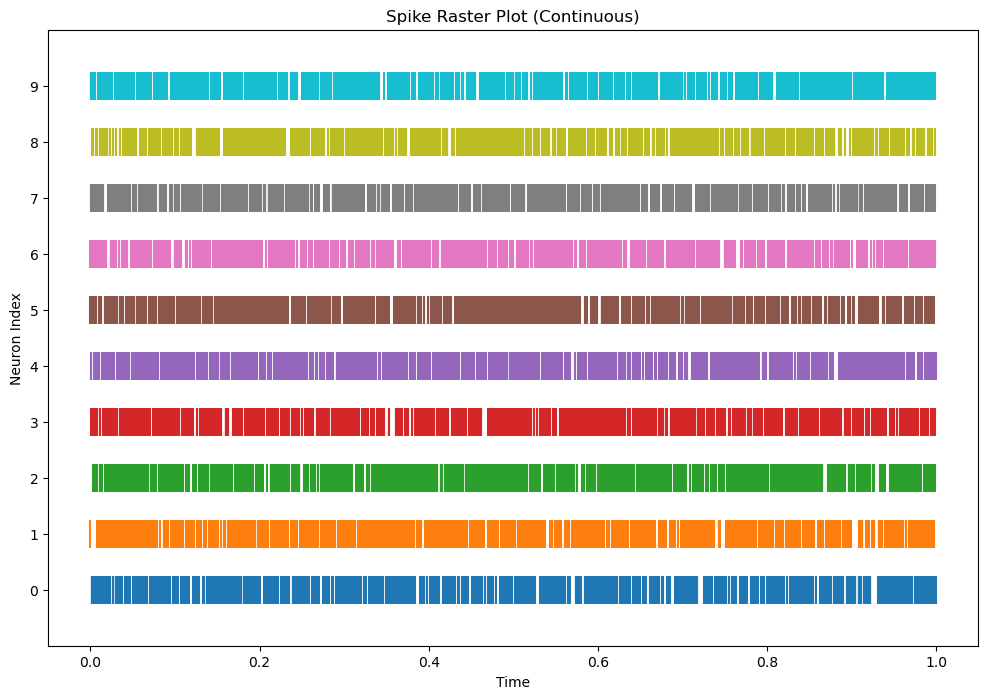

In [10]:
raster_plot(spike_train, colors=None, linelengths=None, figsize=(12,8))

In [11]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
# print(binary_spikes[0][0])

In [12]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
# print(count)
# print(count.shape)

In [13]:
random_indices = np.random.choice(count.shape[0], size=5, replace=False)  # No duplicates
random_samples = count[random_indices]  # Shape: (5, neurons, time)

Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [15]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
# print(raw_excitatory_spike_trains)

In [16]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [17]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

#print(excitatory_spike_trains[0])
#print(inhibitory_spike_trains[0])

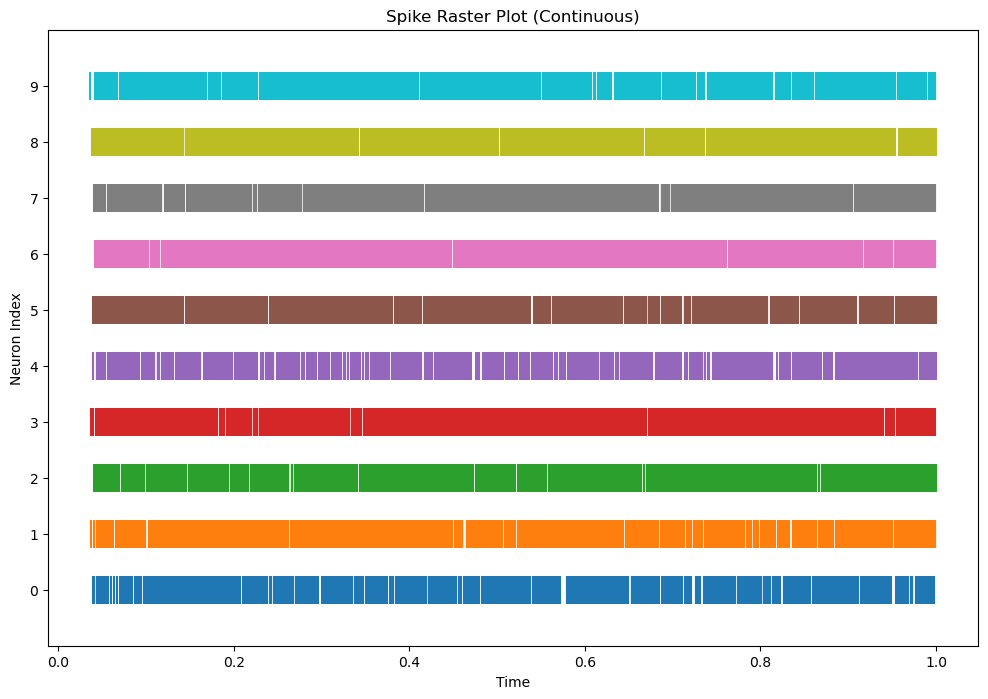

In [18]:
raster_plot(excitatory_spike_trains, colors=None, linelengths=None, figsize=(12,8))

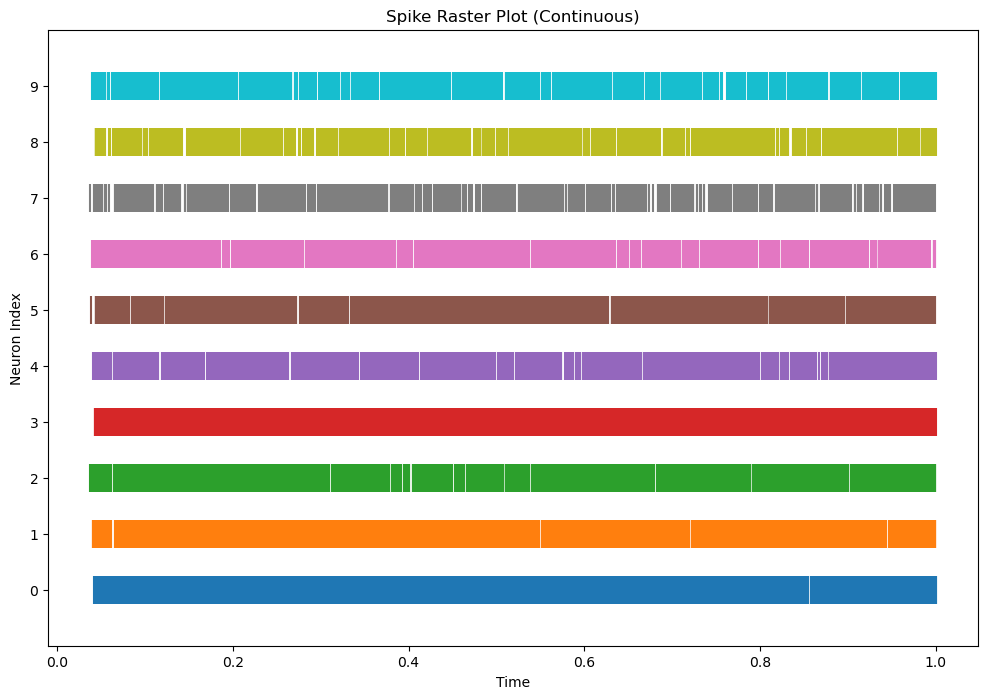

In [19]:
raster_plot(inhibitory_spike_trains, colors=None, linelengths=None, figsize=(12,8))

In [20]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

# print(binary_ex_spikes[0][0]) # first sample of first neuron

In [21]:
spike_count_ex = count_spikes(binary_ex_spikes)
#print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
#print(count_ex[0])
#print(count_ex[1])
#print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
#print(count_in.shape)

In [22]:
random_indices_ex = np.random.choice(count_ex.shape[0], size=5, replace=False)  # No duplicates
random_samples_ex = count_ex[random_indices_ex]  # Shape: (5, neurons, time)

random_indices_in = np.random.choice(count_in.shape[0], size=5, replace=False)  # No duplicates
random_samples_in = count_in[random_indices_in]  # Shape: (5, neurons, time)

Theoretical and Empirical stats of raw counts.

In [24]:
# empirical_mean = empirical_means(count) # np.mean(count, axis=0), count.mean(axis=0)
empirical_mean = count.mean(axis=0)
print(empirical_mean)
print(empirical_mean.shape)
count_rate = empirical_mean[:, -1]
print(count_rate)

# empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
empirical_std_dev = np.sqrt(empirical_mean) #count.std(axis=0, ddof=1)
# empirical_std_dev = (count.std(axis=0)) #newly added, should be the same but isn't
# i fixed the above by using empirical_std_dev = (count.std(axis=0, ddof=1))
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[0.000e+00 2.000e-02 5.000e-02 ... 9.390e+00 9.400e+00 9.420e+00]
 [1.000e-02 1.000e-02 1.000e-02 ... 9.890e+00 9.890e+00 9.890e+00]
 [0.000e+00 0.000e+00 1.000e-02 ... 1.040e+01 1.041e+01 1.041e+01]
 ...
 [2.000e-02 3.000e-02 4.000e-02 ... 1.002e+01 1.003e+01 1.003e+01]
 [0.000e+00 0.000e+00 2.000e-02 ... 9.680e+00 9.690e+00 9.690e+00]
 [2.000e-02 3.000e-02 6.000e-02 ... 1.019e+01 1.020e+01 1.020e+01]]
(10, 1000)
[ 9.42  9.89 10.41  9.75 10.18 10.04  9.51 10.03  9.69 10.2 ]
[[0.         0.14142136 0.2236068  ... 3.06431069 3.06594194 3.06920185]
 [0.1        0.1        0.1        ... 3.14483704 3.14483704 3.14483704]
 [0.         0.         0.1        ... 3.2249031  3.22645316 3.22645316]
 ...
 [0.14142136 0.17320508 0.2        ... 3.16543836 3.16701752 3.16701752]
 [0.         0.         0.14142136 ... 3.11126984 3.11287648 3.11287648]
 [0.14142136 0.17320508 0.24494897 ... 3.19217794 3.19374388 3.19374388]]
(10, 1000)


In [25]:
theoretical_means = calculate_theoretical_mean(count_rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.000000e+00 9.420000e-03 1.884000e-02 ... 9.391740e+00 9.401160e+00
  9.410580e+00]
 [0.000000e+00 9.890000e-03 1.978000e-02 ... 9.860330e+00 9.870220e+00
  9.880110e+00]
 [0.000000e+00 1.041000e-02 2.082000e-02 ... 1.037877e+01 1.038918e+01
  1.039959e+01]
 ...
 [0.000000e+00 1.003000e-02 2.006000e-02 ... 9.999910e+00 1.000994e+01
  1.001997e+01]
 [0.000000e+00 9.690000e-03 1.938000e-02 ... 9.660930e+00 9.670620e+00
  9.680310e+00]
 [0.000000e+00 1.020000e-02 2.040000e-02 ... 1.016940e+01 1.017960e+01
  1.018980e+01]]
(10, 1000)
[[0.         0.09705668 0.13725888 ... 3.06459459 3.06613111 3.06766687]
 [0.         0.09944848 0.14064139 ... 3.14011624 3.14169063 3.14326423]
 [0.         0.10202941 0.14429137 ... 3.22160985 3.22322509 3.22483953]
 ...
 [0.         0.10014989 0.14163333 ... 3.16226343 3.16384892 3.16543362]
 [0.         0.0984378  0.13921207 ... 3.10820366 3.10976205 3.11131966]
 [0.         0.10099505 0.14282857 ... 3.18894967 3.19054854 3.19214661]]
(10, 1000)


In [26]:
res_var = variance_of_residuals(empirical_mean, theoretical_means)
print(res_var)

0.013150214502450271


In [27]:
stands = standardize_counts_loop(count, theoretical_means, theoretical_std_dev, num_samples, num_neurons, exclude = 1)
#print(stands)
#print(stands.shape)
# we removed the very first time point for this dataset

stands_emp = standardize_counts_loop(count, empirical_mean, empirical_std_dev, num_samples, num_neurons, exclude = 100)
#print(stands_emp)
#print(stands_emp.shape)
# we need to remove a few of the first time points for this dataset

# WHENEVER WE CHANGE TIME, WE NEED TO HAVE IT BE KNOWN, 

# when i do covariance, i should reshape from num_samples, num_neurons, time , assume poisson but not assume independent, the variance and covariance should be equal
# time to something with time as replicate. replicate (num_samples) times time in dimension, num_neurons
# covariance, num_neurons by num_neurons, data to produce this should be num_samples times num_neurons
# reformat the current matrix, use reshape with the matrix, maybe with loops 

In [28]:
serialized_count = serialize_counts(stands) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count.shape)
#print(np.mean(serialized_count))
t_stat, p_val_mean = stats.ttest_1samp(serialized_count, np.mean(serialized_count))
print(t_stat)
print(p_val_mean)

    ## per neuron, check that is it doing per neuron
    ## check assumptions if i'm using count, check for data replicate and check for variables


serialized_count_emp = serialize_counts(stands_emp)
#print(serialized_count_emp.shape)
#print(np.mean(serialized_count_emp))
t_stat_emp, p_val_mean_emp = stats.ttest_1samp(serialized_count, np.mean(serialized_count))
print(t_stat_emp)
print(p_val_mean_emp)

0.0
1.0
0.0
1.0


In [29]:
reshaped_stands = np.reshape(stands, (-1, stands.shape[1]), order='F')
#print(stands.shape)
#print(reshaped_stands.shape)

reshaped_stands_emp = np.reshape(stands_emp, (-1, stands_emp.shape[1]), order='F')
#print(stands_emp.shape)
#print(reshaped_stands_emp.shape)

In [30]:
#hotelling_result = hotelling_t2_test(serialized_count, [0,0], bessel=True, S=None)
#print(hotelling_result)

In [31]:
#good_result = stats.goodness_of_fit(stats.norm, reshaped_stands, statistic='ad', n_mc_samples=9999, rng=None)
# Anderson-Darling test (good for normality)
# Number of Monte Carlo samples
# Random number generator (None for fresh results)

#print(f"Statistic: {good_result.statistic}")
#print(f"P-value: {good_result.pvalue}")
#print(f"Location (mean): {good_result.fit_result.params.loc}")
#print(f"Scale (std dev): {good_result.fit_result.params.scale}")

In [32]:
#cov_matrix, diagonal_ones = covariance_diagonal(reshaped_stands, tol=1e-8)
#print(cov_matrix)
#print(diagonal_ones)
#cov_matrix_emp, diagonal_ones_emp = covariance_diagonal(reshaped_stands_emp, tol=1e-8)
#print(cov_matrix_emp)
#print(diagonal_ones_emp)

array([[ 9.47695974e-01,  4.59075797e-03, -1.80468769e-04,
        -2.63550196e-03, -2.03368748e-02,  1.21504177e-02,
        -7.54295144e-04,  1.87304983e-02, -3.92527088e-03,
         6.98190486e-03],
       [ 4.59075797e-03,  1.02549470e+00,  9.06890808e-03,
         4.48063984e-02,  2.57762127e-02, -2.49886589e-02,
        -2.46764863e-03, -4.97813145e-03,  1.06282264e-02,
        -4.51723379e-03],
       [-1.80468769e-04,  9.06890808e-03,  1.06508976e+00,
        -3.24419097e-03,  3.26065258e-02,  1.74243860e-02,
        -5.31639570e-02,  1.89717115e-02,  1.40585441e-02,
        -1.08537266e-02],
       [-2.63550196e-03,  4.48063984e-02, -3.24419097e-03,
         1.07169171e+00, -2.97653838e-02,  2.87273248e-03,
         2.57542168e-02, -5.28737694e-02, -2.34331818e-03,
         1.88380640e-02],
       [-2.03368748e-02,  2.57762127e-02,  3.26065258e-02,
        -2.97653838e-02,  1.11695304e+00, -4.29169814e-02,
         9.01913909e-03,  4.37463783e-02, -5.56969145e-02,
        -2.

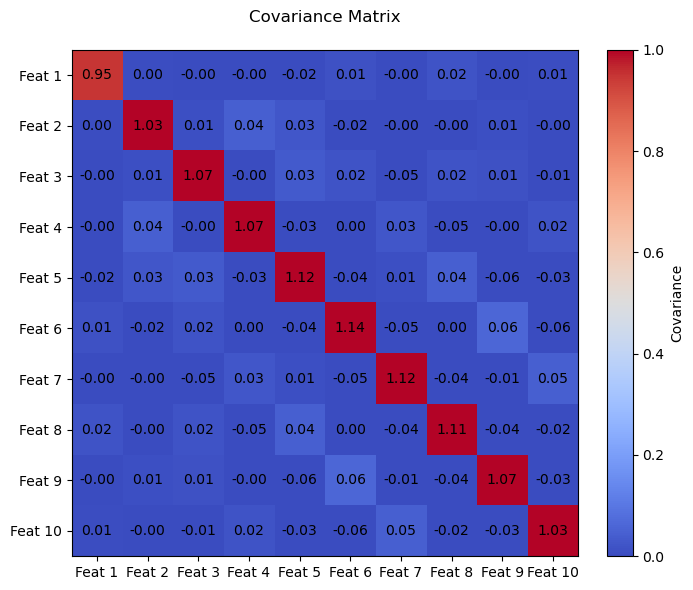

In [33]:
plot_covariance_matrix(reshaped_stands, normalize=False, title=None, cmap='coolwarm', annot=True)

array([[1.00250541, 0.80505954, 0.68938092, 0.6201844 , 0.58228546,
        0.53268843, 0.49162846, 0.46927344, 0.43940245, 0.41733555],
       [0.80505954, 1.03422057, 0.89885456, 0.81715306, 0.76505547,
        0.70586161, 0.65759985, 0.61872607, 0.58190136, 0.54832514],
       [0.68938092, 0.89885456, 1.05085708, 0.95622123, 0.89765818,
        0.83027808, 0.77459701, 0.73447713, 0.68766663, 0.64719366],
       [0.6201844 , 0.81715306, 0.95622123, 1.07606707, 1.0106591 ,
        0.93304819, 0.86760045, 0.81915059, 0.76668562, 0.72184636],
       [0.58228546, 0.76505547, 0.89765818, 1.0106591 , 1.12467733,
        1.0382972 , 0.96852344, 0.91405348, 0.85035094, 0.80386591],
       [0.53268843, 0.70586161, 0.83027808, 0.93304819, 1.0382972 ,
        1.1111623 , 1.03947005, 0.98343245, 0.91647765, 0.8641162 ],
       [0.49162846, 0.65759985, 0.77459701, 0.86760045, 0.96852344,
        1.03947005, 1.0999278 , 1.04136427, 0.97171671, 0.9147404 ],
       [0.46927344, 0.61872607, 0.7344771

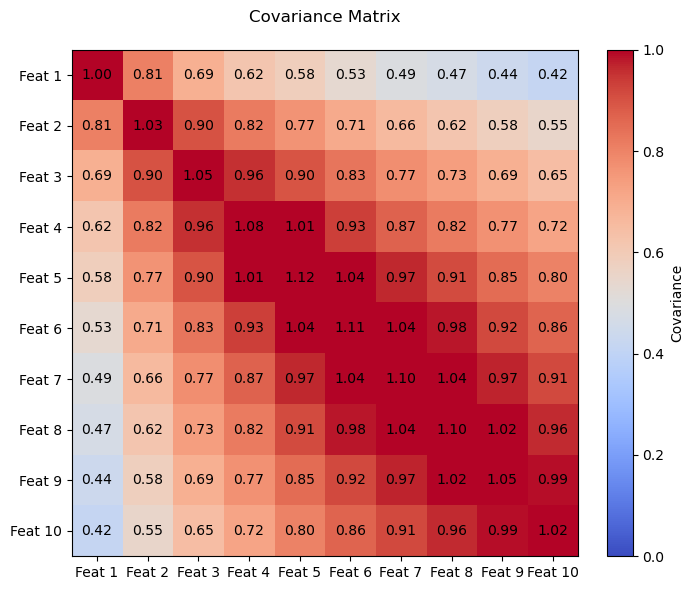

In [34]:
plot_covariance_matrix(reshaped_stands_emp, normalize=False, title=None, cmap='coolwarm', annot=True)

In [35]:
# MULTIVARIATE ANALYSIS
# rv = multivariate_normal(mean=mean, cov=cov, allow_singular=allow_singular)
#rv = multivariate_normal(mean = [0,0], cov = cov_matrix, allow_singular = False)
#rv_emp = multivariate_normal(mean = [0,0], cov = cov_matrix_emp, allow_singular=False)
#print(rv)
#print(rv_emp)

# this is creating its own model, from this we can test if the data has goodness of fit

Theoretical and Empirical stats of excitatory counts.

In [37]:
# empirical_mean_ex = empirical_means(count_ex)
empirical_mean_ex = count_ex.mean(axis=0)
print(empirical_mean_ex)
print(empirical_mean_ex.shape)
count_rate_ex = empirical_mean_ex[:, -1]

# empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
empirical_std_dev_ex = count_ex.std(axis=0, ddof=1)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)
# print(empirical_lower_bound_sim_ex)
# print(empirical_upper_bound_sim_ex)

[[ 0.    0.    0.   ... 11.99 12.   12.  ]
 [ 0.    0.    0.   ... 15.58 15.62 15.64]
 [ 0.    0.    0.   ... 16.76 16.79 16.82]
 ...
 [ 0.    0.    0.   ... 18.98 19.   19.01]
 [ 0.    0.    0.   ... 17.56 17.58 17.59]
 [ 0.    0.    0.   ... 14.86 14.89 14.89]]
(10, 1000)
[[0.         0.         0.         ... 1.94102441 1.93844674 1.93844674]
 [0.         0.         0.         ... 1.73601192 1.69240729 1.69085478]
 [0.         0.         0.         ... 1.66436204 1.65324902 1.68403076]
 ...
 [0.         0.         0.         ... 1.73484782 1.71740937 1.72031827]
 [0.         0.         0.         ... 1.88197189 1.90257667 1.90212534]
 [0.         0.         0.         ... 1.66375503 1.64467307 1.64467307]]
(10, 1000)


In [38]:
theoretical_means_sim_ex = calculate_theoretical_mean(count_rate_ex, time)
print(theoretical_means_sim_ex)
print(theoretical_means_sim_ex.shape)

theoretical_std_dev_sim_ex = calculate_theoretical_std_dev(theoretical_means_sim_ex)
print(theoretical_std_dev_sim_ex)
print(theoretical_std_dev_sim_ex.shape)

theoretical_lower_bound_sim_ex, theoretical_upper_bound_sim_ex = confidence_intervals(theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound_sim_ex)
# print(theoretical_upper_bound_sim_ex)

[[0.000000e+00 1.200000e-02 2.400000e-02 ... 1.196400e+01 1.197600e+01
  1.198800e+01]
 [0.000000e+00 1.564000e-02 3.128000e-02 ... 1.559308e+01 1.560872e+01
  1.562436e+01]
 [0.000000e+00 1.682000e-02 3.364000e-02 ... 1.676954e+01 1.678636e+01
  1.680318e+01]
 ...
 [0.000000e+00 1.901000e-02 3.802000e-02 ... 1.895297e+01 1.897198e+01
  1.899099e+01]
 [0.000000e+00 1.759000e-02 3.518000e-02 ... 1.753723e+01 1.755482e+01
  1.757241e+01]
 [0.000000e+00 1.489000e-02 2.978000e-02 ... 1.484533e+01 1.486022e+01
  1.487511e+01]]
(10, 1000)
[[0.         0.10954451 0.15491933 ... 3.45890156 3.46063578 3.46236913]
 [0.         0.12505999 0.17686153 ... 3.94880741 3.95078726 3.95276612]
 [0.         0.12969194 0.1834121  ... 4.09506288 4.09711606 4.09916821]
 ...
 [0.         0.13787676 0.19498718 ... 4.35350089 4.35568364 4.3578653 ]
 [0.         0.1326273  0.18756332 ... 4.1877476  4.18984725 4.19194585]
 [0.         0.12202459 0.17256883 ... 3.85296379 3.85489559 3.85682642]]
(10, 1000)


In [39]:
res_var_ex = variance_of_residuals(empirical_mean_ex, theoretical_means_sim_ex)
print(res_var_ex)

0.03397873407940787


In [40]:
stands_ex = standardize_counts_loop(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, num_neurons, exclude = 1)
#print(stands_ex)
#print(stands_ex.shape)

stands_ex_emp = standardize_counts_loop(count_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples, num_neurons, exclude = 300)
#print(stands_ex_emp)
#print(stands_ex_emp.shape)

# WHENEVER WE CHANGE TIME, WE NEED TO HAVE IT BE KNOWN, 

# when i do covariance, i should reshape from num_samples, num_neurons, , assume poisson but not assume independent, the variance and covariance should be equal
# time to something with time as replicate. replicate (num_samples) times time in dimension, num_neurons
# covariance, num_neurons by num_neurons, data to produce this should be num_samples times num_neurons
# reformat the current matrix, use reshape with the matrix, maybe with loops 

In [41]:
serialized_count_ex = serialize_counts(stands_ex) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_ex.shape)
#print(np.mean(serialized_count_ex))
t_stat_ex, p_val_mean_ex = stats.ttest_1samp(serialized_count_ex, np.mean(serialized_count_ex))
#print(t_stat_ex)
#print(p_val_mean_ex)

    ## per neuron, check that is it doing per neuron
    ## check assumptions if i'm using count, check for data replicate and check for variables

serialized_count_ex_emp = serialize_counts(stands_ex_emp) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_ex_emp.shape)
#print(np.mean(serialized_count_ex_emp))
t_stat_ex_emp, p_val_mean_ex_emp = stats.ttest_1samp(serialized_count_ex_emp, np.mean(serialized_count_ex_emp))
#print(t_stat_ex_emp)
#print(p_val_mean_ex_emp)

In [42]:
reshaped_stands_ex = np.reshape(stands_ex, (-1, stands_ex.shape[1]), order='F')
#print(stands_ex.shape)
#print(reshaped_stands_ex.shape)

reshaped_stands_ex_emp = np.reshape(stands_ex_emp, (-1, stands_ex_emp.shape[1]), order='F')
#print(stands_ex_emp.shape)
#print(reshaped_stands_ex_emp.shape)

In [43]:
#cov_matrix_ex, diagonal_ones_ex = covariance_diagonal(reshaped_stands_ex, tol=1e-8)
#print(cov_matrix_ex)
#print(diagonal_ones_ex)
#cov_matrix_ex_emp, diagonal_ones_ex_emp = covariance_diagonal(reshaped_stands_ex_emp, tol=1e-8)
#print(cov_matrix_ex_emp)
#print(diagonal_ones_ex_emp)

array([[0.14902556, 0.00686662, 0.0033134 , 0.0072989 , 0.00611901,
        0.00639106, 0.00251706, 0.00311596, 0.00355801, 0.00433906],
       [0.00686662, 0.19338858, 0.01021053, 0.00679664, 0.0208428 ,
        0.00591567, 0.01404789, 0.0062475 , 0.00631751, 0.00239992],
       [0.0033134 , 0.01021053, 0.18284986, 0.01125694, 0.01140118,
        0.01866215, 0.00832961, 0.01499718, 0.00746472, 0.00922634],
       [0.0072989 , 0.00679664, 0.01125694, 0.17750181, 0.02059564,
        0.01727834, 0.02232804, 0.01442427, 0.01886742, 0.006749  ],
       [0.00611901, 0.0208428 , 0.01140118, 0.02059564, 0.18039898,
        0.02426121, 0.02355105, 0.02730691, 0.02229728, 0.0231166 ],
       [0.00639106, 0.00591567, 0.01866215, 0.01727834, 0.02426121,
        0.19204191, 0.02834718, 0.02370936, 0.02967384, 0.02327378],
       [0.00251706, 0.01404789, 0.00832961, 0.02232804, 0.02355105,
        0.02834718, 0.19677218, 0.02735768, 0.02900844, 0.02901729],
       [0.00311596, 0.0062475 , 0.0149971

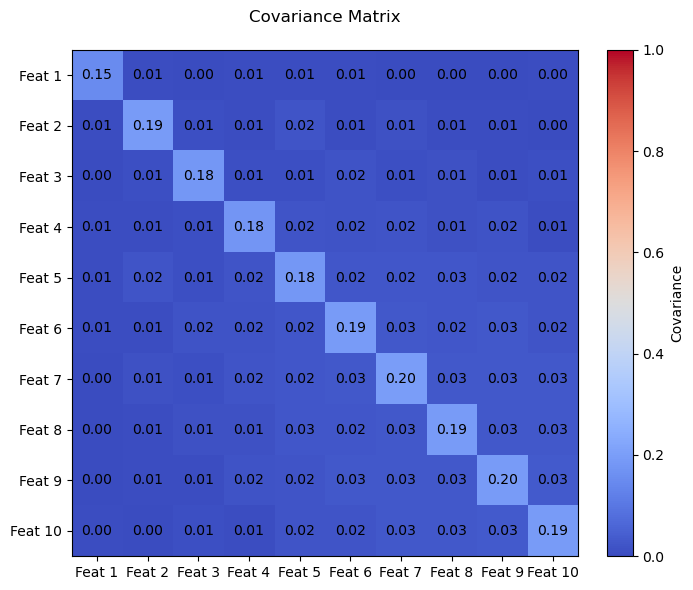

In [44]:
plot_covariance_matrix(reshaped_stands_ex, normalize=False, title=None, cmap='coolwarm', annot=True)

array([[0.99001414, 0.82682067, 0.75821984, 0.7098939 , 0.66925488,
        0.63766764, 0.60982656, 0.59290946, 0.56336714, 0.54882734],
       [0.82682067, 0.99001414, 0.85141855, 0.79527059, 0.75386685,
        0.71533153, 0.69069773, 0.6668884 , 0.6398551 , 0.62310355],
       [0.75821984, 0.85141855, 0.99001414, 0.87753356, 0.83385897,
        0.78956282, 0.76523197, 0.73709977, 0.71046216, 0.68927728],
       [0.7098939 , 0.79527059, 0.87753356, 0.99001414, 0.89519243,
        0.84586204, 0.82189535, 0.78794649, 0.76172155, 0.73734392],
       [0.66925488, 0.75386685, 0.83385897, 0.89519243, 0.99001414,
        0.90168359, 0.86567265, 0.83469056, 0.80881536, 0.78092018],
       [0.63766764, 0.71533153, 0.78956282, 0.84586204, 0.90168359,
        0.99001414, 0.91465116, 0.87877394, 0.8519666 , 0.81881205],
       [0.60982656, 0.69069773, 0.76523197, 0.82189535, 0.86567265,
        0.91465116, 0.99001414, 0.91929353, 0.89197078, 0.8568123 ],
       [0.59290946, 0.6668884 , 0.7370997

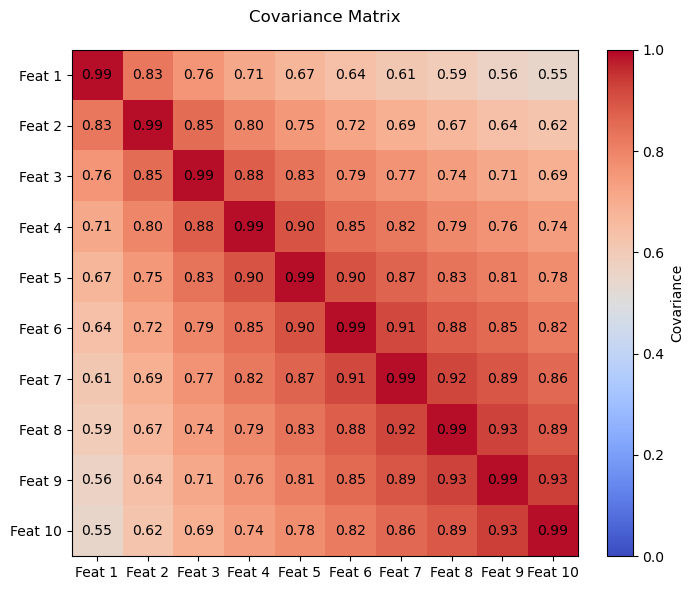

In [45]:
plot_covariance_matrix(reshaped_stands_ex_emp, normalize=False, title=None, cmap='coolwarm', annot=True)

In [46]:
# MULTIVARIATE ANALYSIS
# rv = multivariate_normal(mean=mean, cov=cov, allow_singular=allow_singular)

# rv_ex = multivariate_normal(mean = theoretical_means_sim_ex, cov = cov_matrix_ex, allow_singular=allow_singular)
# rv_ex_emp = multivariate_normal(mean = empirical_mean_ex, cov = cov_matrix_ex_emp, allow_singular=allow_singular)

# this is creating its own model, from this we can test if the data has goodness of fit

Theoretical and Empirical stats of inhibitory counts.

In [48]:
# empirical_mean_in = empirical_means(count_in)
empirical_mean_in = count_in.mean(axis=0)
print(empirical_mean_in)
print(empirical_mean_in.shape)
count_rate_in = empirical_mean_in[:, -1]

#empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
empirical_std_dev_in = count_in.std(axis=0, ddof=1)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)
# print(empirical_lower_bound_sim_in)
# print(empirical_upper_bound_sim_in)

[[ 0.    0.    0.   ... 25.14 25.16 25.21]
 [ 0.    0.    0.   ... 23.45 23.49 23.51]
 [ 0.    0.    0.   ... 18.72 18.74 18.75]
 ...
 [ 0.    0.    0.   ... 10.88 10.9  10.9 ]
 [ 0.    0.    0.   ... 13.27 13.3  13.32]
 [ 0.    0.    0.   ... 13.07 13.08 13.1 ]]
(10, 1000)
[[0.         0.         0.         ... 1.79235188 1.807504   1.82183723]
 [0.         0.         0.         ... 1.59148619 1.59224763 1.61116684]
 [0.         0.         0.         ... 1.63965998 1.61820452 1.61667448]
 ...
 [0.         0.         0.         ... 2.02649122 2.03752672 2.03752672]
 [0.         0.         0.         ... 1.61342224 1.59861051 1.62605055]
 [0.         0.         0.         ... 1.69523992 1.69777037 1.72620914]]
(10, 1000)


In [49]:
theoretical_means_sim_in = calculate_theoretical_mean(count_rate_in, time)
print(theoretical_means_sim_in)
print(theoretical_means_sim_in.shape)

theoretical_std_dev_sim_in = calculate_theoretical_std_dev(theoretical_means_sim_in)
print(theoretical_std_dev_sim_in)
print(theoretical_std_dev_sim_in.shape)

theoretical_lower_bound_sim_in, theoretical_upper_bound_sim_in = confidence_intervals(theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound_sim_in)
# print(theoretical_upper_bound_sim_in)

[[0.000000e+00 2.521000e-02 5.042000e-02 ... 2.513437e+01 2.515958e+01
  2.518479e+01]
 [0.000000e+00 2.351000e-02 4.702000e-02 ... 2.343947e+01 2.346298e+01
  2.348649e+01]
 [0.000000e+00 1.875000e-02 3.750000e-02 ... 1.869375e+01 1.871250e+01
  1.873125e+01]
 ...
 [0.000000e+00 1.090000e-02 2.180000e-02 ... 1.086730e+01 1.087820e+01
  1.088910e+01]
 [0.000000e+00 1.332000e-02 2.664000e-02 ... 1.328004e+01 1.329336e+01
  1.330668e+01]
 [0.000000e+00 1.310000e-02 2.620000e-02 ... 1.306070e+01 1.307380e+01
  1.308690e+01]]
(10, 1000)
[[0.         0.15877657 0.22454398 ... 5.01341899 5.01593262 5.01844498]
 [0.         0.15332971 0.21684096 ... 4.84143264 4.84386003 4.84628621]
 [0.         0.13693064 0.19364917 ... 4.32362695 4.32579472 4.32796141]
 ...
 [0.         0.10440307 0.14764823 ... 3.29655881 3.29821164 3.29986363]
 [0.         0.1154123  0.16321765 ... 3.64417892 3.64600603 3.64783223]
 [0.         0.11445523 0.16186414 ... 3.61395905 3.61577101 3.61758207]]
(10, 1000)


In [50]:
res_var_in = variance_of_residuals(empirical_mean_in, theoretical_means_sim_in)
print(res_var_in)

0.043511751873937424


In [51]:
stands_in = standardize_counts_loop(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, num_neurons, exclude = 1)
#print(stands_in)
#print(stands_in.shape)

stands_in_emp = standardize_counts_loop(count_in, empirical_mean_in, empirical_std_dev_in, num_samples, num_neurons, exclude = 300)
#print(stands_in_emp)
#print(stands_in_emp.shape)

# WHENEVER WE CHANGE TIME, WE NEED TO HAVE IT BE KNOWN, 

# when i do covariance, i should reshape from num_samples, num_neurons, , assume poisson but not assume independent, the variance and covariance should be equal
# time to something with time as replicate. replicate (num_samples) times time in dimension, num_neurons
# covariance, num_neurons by num_neurons, data to produce this should be num_samples times num_neurons
# reformat the current matrix, use reshape with the matrix, maybe with loops 

In [52]:
serialized_count_in = serialize_counts(stands_in) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_in.shape)
#print(np.mean(serialized_count_in))
t_stat_in, p_val_mean_in = stats.ttest_1samp(serialized_count_in, np.mean(serialized_count_in))
#print(t_stat_in)
#print(p_val_mean_in)
    ## per neuron, check that is it doing per neuron
    ## check assumptions if i'm using count, check for data replicate and check for variables


serialized_count_in_emp = serialize_counts(stands_in_emp) # make serialize have an extra parameter that makes you drop the first n units [:,:,10:]
#print(serialized_count_in_emp.shape)
#print(np.mean(serialized_count_in_emp))
t_stat_in_emp, p_val_mean_in_emp = stats.ttest_1samp(serialized_count_in_emp, np.mean(serialized_count_in_emp))
#print(t_stat_in_emp)
#print(p_val_mean_in_emp)

In [53]:
reshaped_stands_in = np.reshape(stands_in, (-1, stands_in.shape[1]), order='F')
#print(stands_in.shape)
#print(reshaped_stands_in.shape)

reshaped_stands_in_emp = np.reshape(stands_in_emp, (-1, stands_in_emp.shape[1]), order='F')
#print(stands_in_emp.shape)
#print(reshaped_stands_in_emp.shape)

In [54]:
#cov_matrix_in, diagonal_ones_in = covariance_diagonal(reshaped_stands_in, tol=1e-8)
#print(cov_matrix_in)
#print(diagonal_ones_in)
#cov_matrix_in_emp, diagonal_ones_in_emp = covariance_diagonal(reshaped_stands_in_emp, tol=1e-8)
#print(cov_matrix_in_emp)
#print(diagonal_ones_in_emp)

array([[ 1.48290040e-01,  1.59949234e-03,  3.55195148e-03,
        -1.95357001e-03,  3.21606762e-03, -1.40708644e-03,
         1.22357472e-03,  5.67279612e-03,  6.77811635e-03,
         6.14749927e-04],
       [ 1.59949234e-03,  1.77821163e-01,  6.04109655e-03,
         9.39256539e-03, -1.44020450e-03, -1.90914028e-03,
        -4.51878328e-03, -3.06201865e-03,  5.30083791e-03,
         8.86113335e-04],
       [ 3.55195148e-03,  6.04109655e-03,  1.74120177e-01,
         8.25036274e-03,  1.58989051e-02,  3.10239458e-03,
         2.12182161e-03, -4.97671322e-03, -5.00259063e-03,
         9.08098858e-03],
       [-1.95357001e-03,  9.39256539e-03,  8.25036274e-03,
         1.77197906e-01,  1.06629074e-02,  1.48019964e-02,
         3.38689592e-03, -1.14811937e-04, -2.63003074e-03,
        -3.50501056e-04],
       [ 3.21606762e-03, -1.44020450e-03,  1.58989051e-02,
         1.06629074e-02,  1.80799168e-01,  8.55377111e-03,
         1.18462206e-02,  7.46178728e-03,  3.73316145e-03,
         5.

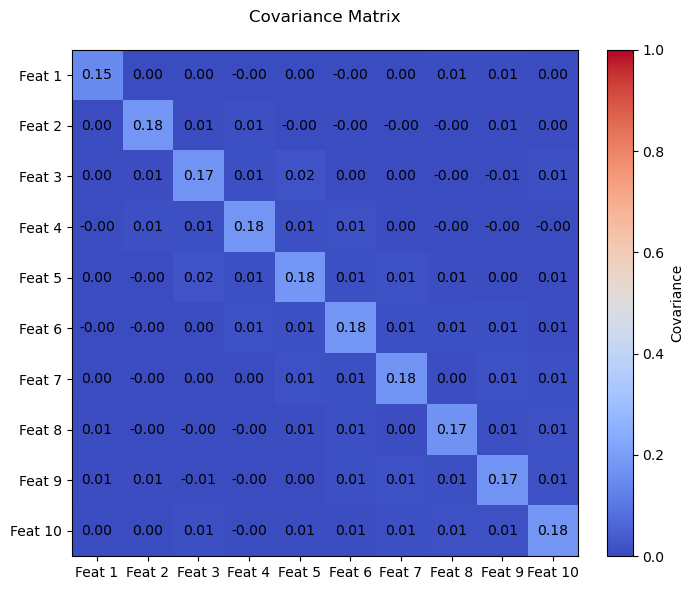

In [55]:
plot_covariance_matrix(reshaped_stands_in, normalize=False, title=None, cmap='coolwarm', annot=True)

array([[0.99001414, 0.82727396, 0.76122884, 0.713448  , 0.67170809,
        0.63307346, 0.59791103, 0.56482132, 0.5509802 , 0.52398246],
       [0.82727396, 0.99001414, 0.85671047, 0.79609867, 0.75679216,
        0.7127018 , 0.67517431, 0.63965256, 0.62129045, 0.59170035],
       [0.76122884, 0.85671047, 0.99001414, 0.87423752, 0.8290664 ,
        0.78154704, 0.7416754 , 0.70369978, 0.68065548, 0.65150664],
       [0.713448  , 0.79609867, 0.87423752, 0.99001414, 0.89026979,
        0.84063769, 0.79937831, 0.76416622, 0.73729112, 0.70740025],
       [0.67170809, 0.75679216, 0.8290664 , 0.89026979, 0.99001414,
        0.89720213, 0.85303856, 0.81553852, 0.78790945, 0.75751072],
       [0.63307346, 0.7127018 , 0.78154704, 0.84063769, 0.89720213,
        0.99001414, 0.90613855, 0.86476163, 0.83344662, 0.80015414],
       [0.59791103, 0.67517431, 0.7416754 , 0.79937831, 0.85303856,
        0.90613855, 0.99001414, 0.9123466 , 0.88244862, 0.84706537],
       [0.56482132, 0.63965256, 0.7036997

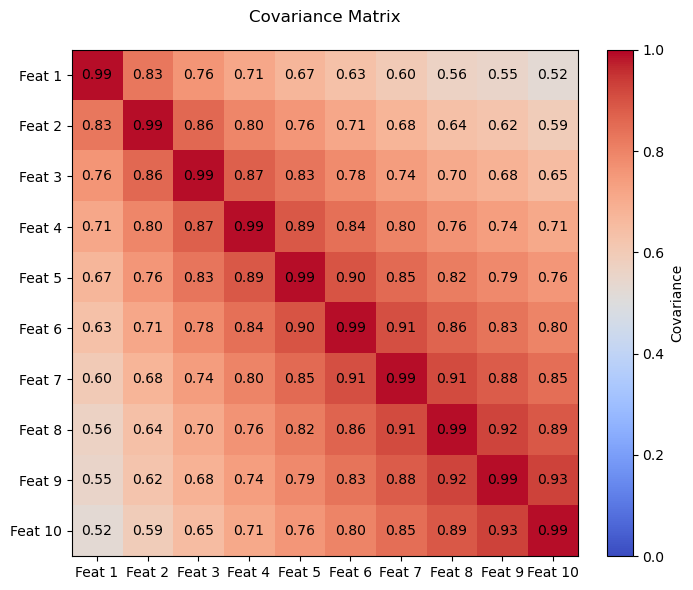

In [56]:
plot_covariance_matrix(reshaped_stands_in_emp, normalize=False, title=None, cmap='coolwarm', annot=True)

In [57]:
# MULTIVARIATE ANALYSIS
# rv = multivariate_normal(mean=mean, cov=cov, allow_singular=allow_singular)

# rv_in = multivariate_normal(mean = theoretical_means_sim_in, cov = cov_matrix_in, allow_singular=allow_singular)
# rv_in_emp = multivariate_normal(mean = empirical_mean_in, cov = cov_matrix_in_emp, allow_singular=allow_singular)

# this is creating its own model, from this we can test if the data has goodness of fit

Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

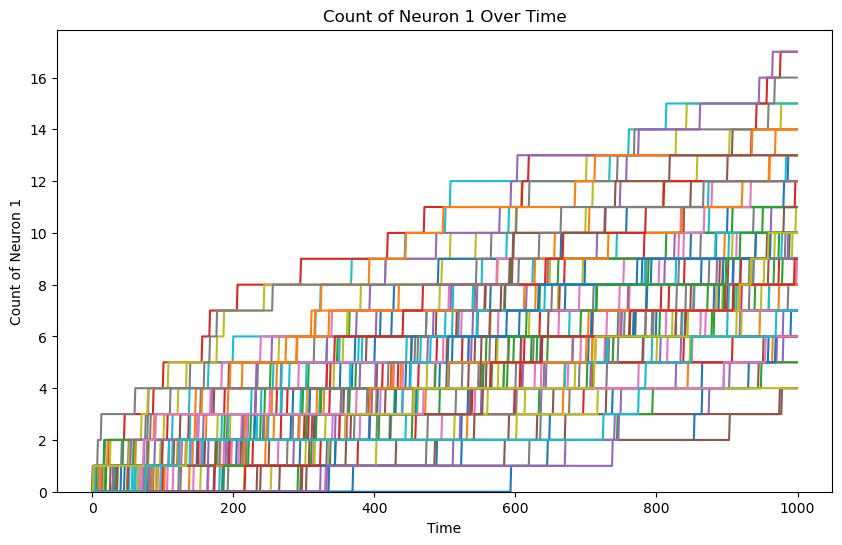

In [59]:
# plot_count_neuron1_vs_time(random_samples, num_samples = 5)
plot_count_neuron1_vs_time(count, num_samples)

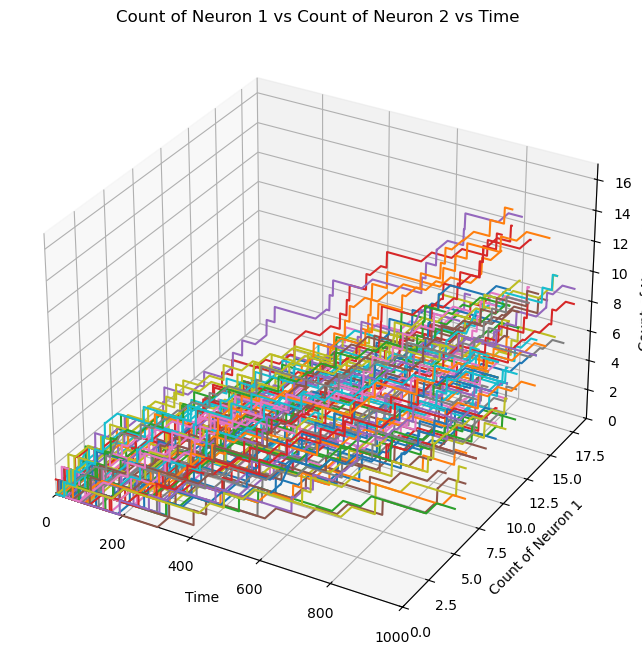

In [60]:
plot_count_neuron1_vs_neuron2_vs_time(count, num_samples)

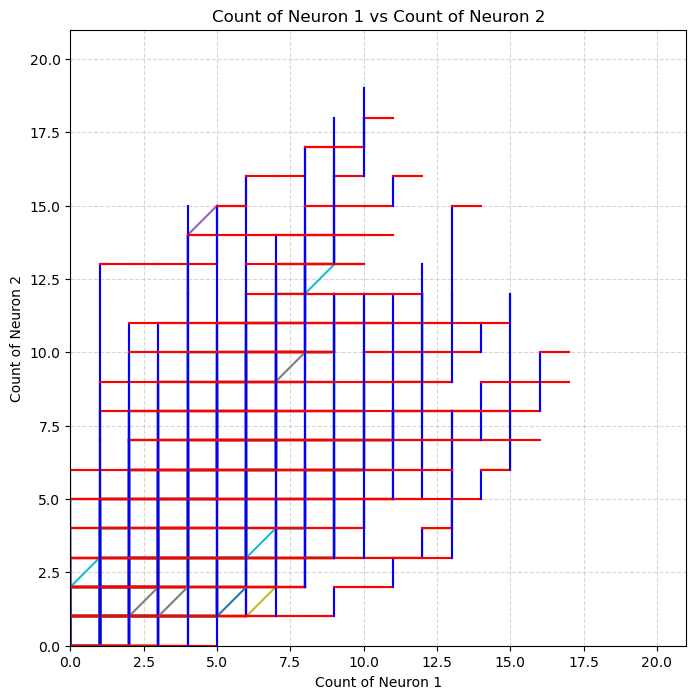

In [61]:
plot_count_neuron1_vs_count_neuron2(count, num_samples)

In [62]:
# plot_count_neuron1_vs_count_neuron2_vs_count_neuron3(count, num_samples)

In [63]:
# combined_poisson_plot(spike_train, count, theoretical_means, empirical_mean, colors=None, figsize=(12, 10))

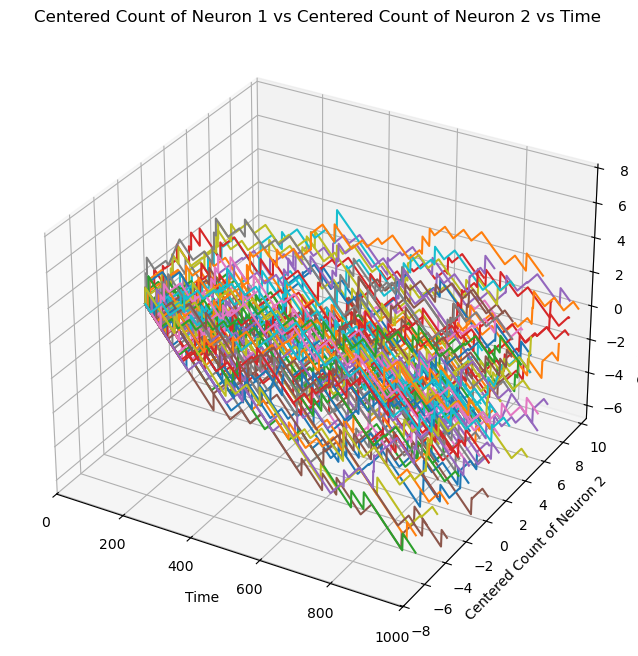

In [64]:
#plot_centered_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, num_samples=5)
plot_centered_staircase_3d(count, theoretical_means, theoretical_std_dev, num_samples)

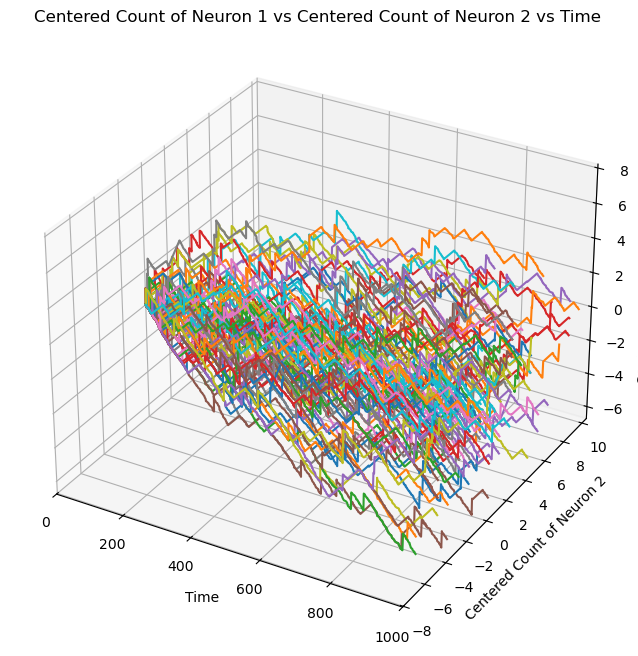

In [65]:
#plot_centered_staircase_3d(random_samples, empirical_mean, empirical_std_dev, num_samples= 5)
plot_centered_staircase_3d(count, empirical_mean, empirical_std_dev, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:9: RuntimeWarning: divide by zero encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


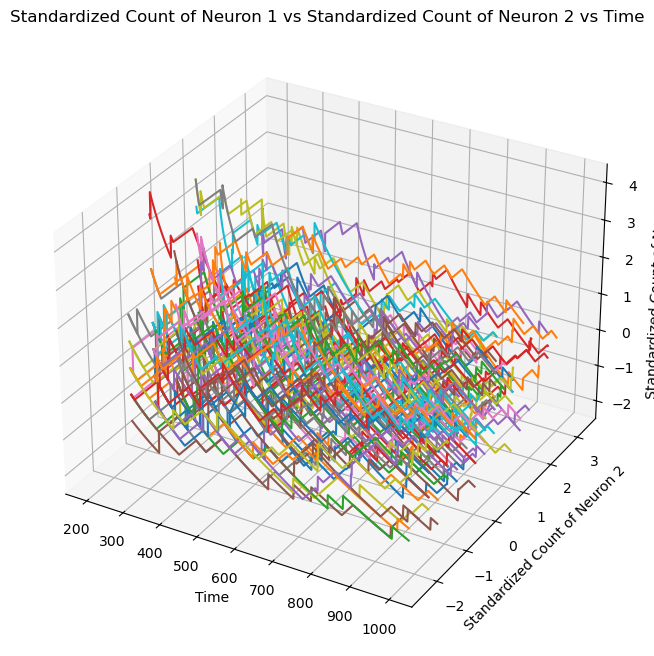

In [66]:
#plot_standardized_staircase_3d(random_samples, theoretical_means, theoretical_std_dev, t0, num_samples=5)
plot_standardized_staircase_3d(count, theoretical_means, theoretical_std_dev, t0, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]


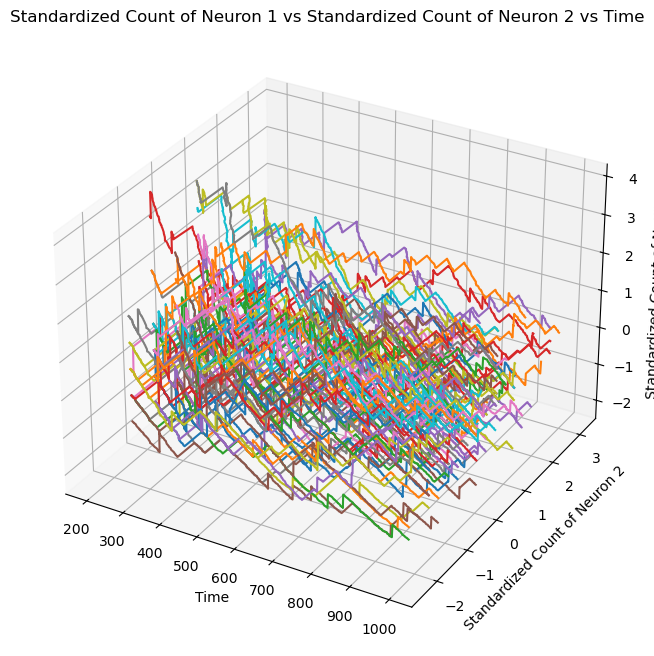

In [67]:
#plot_standardized_staircase_3d(random_samples, empirical_mean, empirical_std_dev, t0, num_samples=5)
plot_standardized_staircase_3d(count, empirical_mean, empirical_std_dev, t0, num_samples)

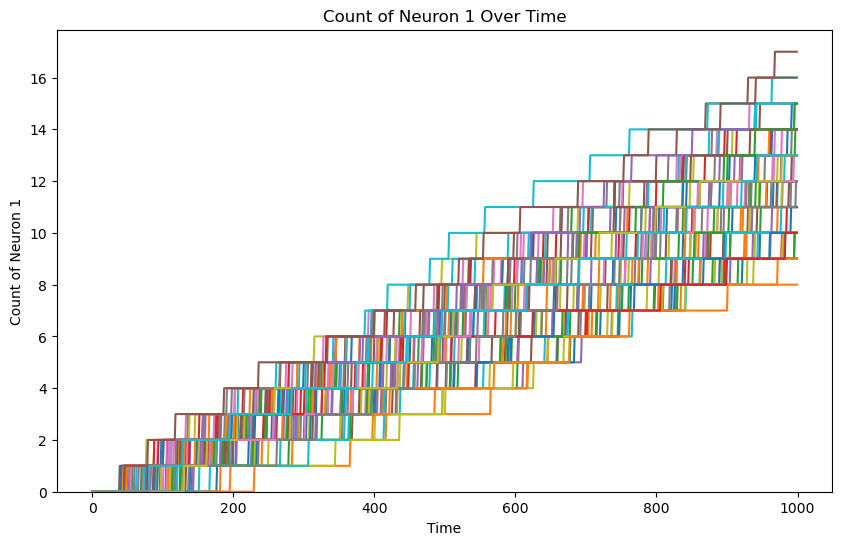

In [68]:
#plot_count_neuron1_vs_time(random_samples_ex, num_samples = 5)
plot_count_neuron1_vs_time(count_ex, num_samples)

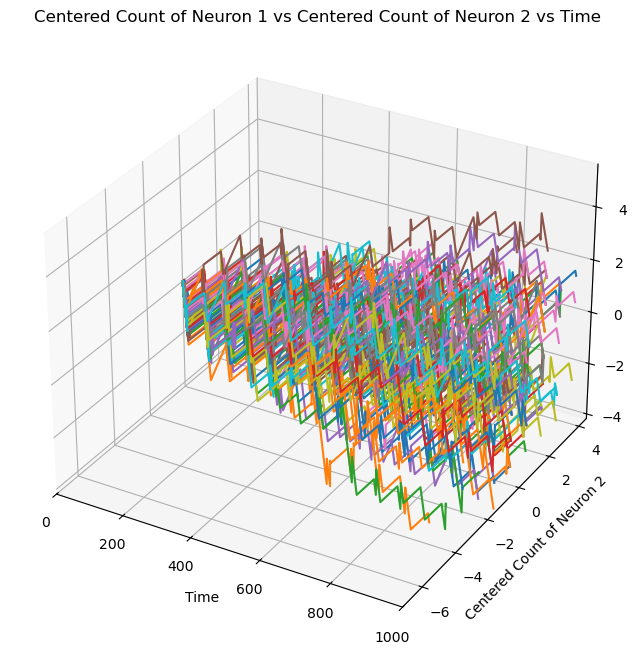

In [69]:
#plot_centered_staircase_3d(random_samples_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples= 5)
plot_centered_staircase_3d(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples)

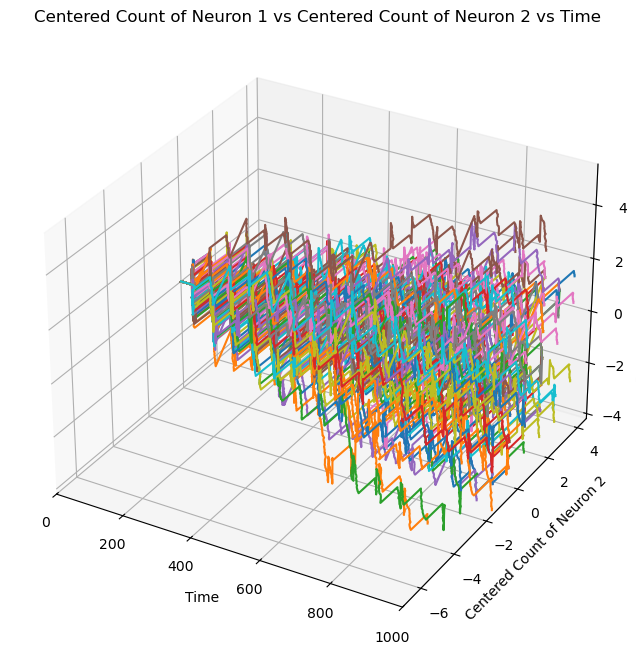

In [70]:
#plot_centered_staircase_3d(random_samples_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples= 5)
plot_centered_staircase_3d(count_ex, empirical_mean_ex, empirical_std_dev_ex, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


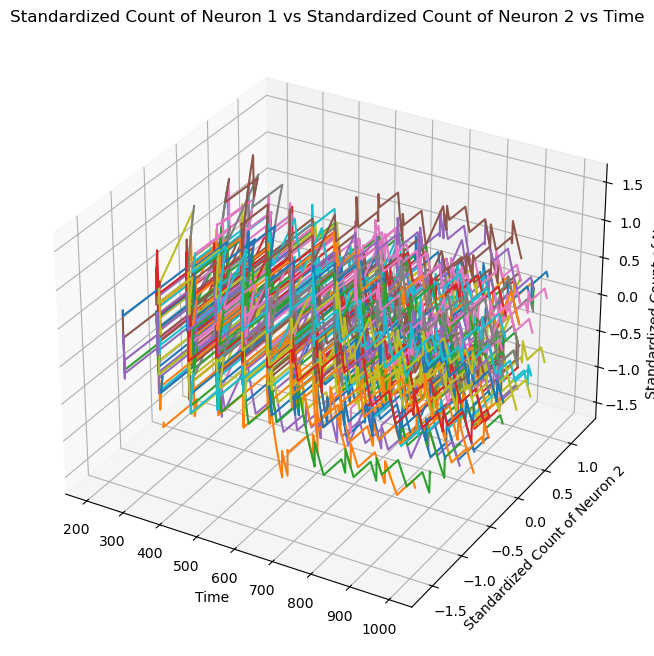

In [71]:
#plot_standardized_staircase_3d(random_samples_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0, num_samples=5)
plot_standardized_staircase_3d(count_ex, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


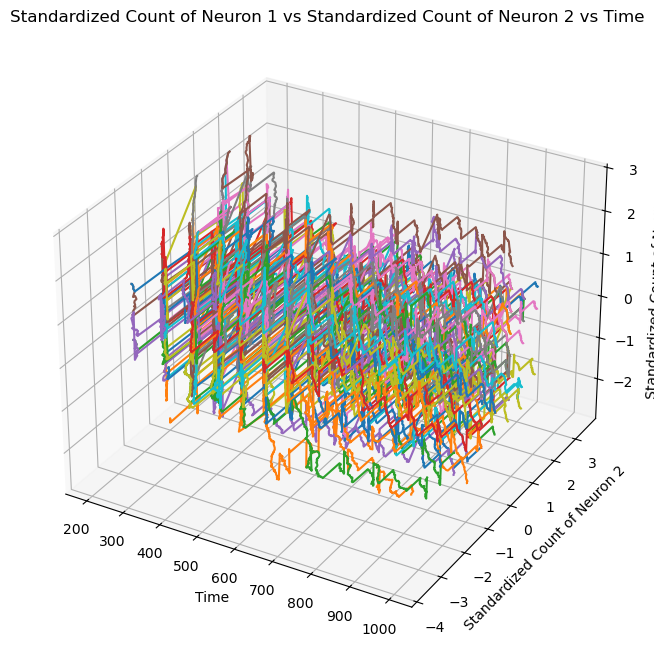

In [72]:
#plot_standardized_staircase_3d(random_samples_ex, empirical_mean_ex, empirical_std_dev_ex, t0, num_samples=5)
plot_standardized_staircase_3d(count_ex, empirical_mean_ex, empirical_std_dev_ex, t0, num_samples)

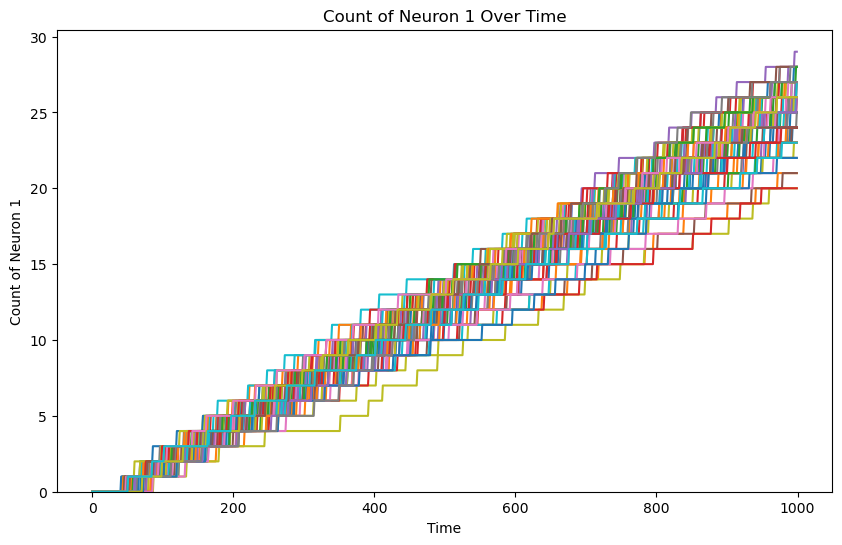

In [73]:
#plot_count_neuron1_vs_time(random_samples_in, num_samples = 5)
plot_count_neuron1_vs_time(count_in, num_samples)

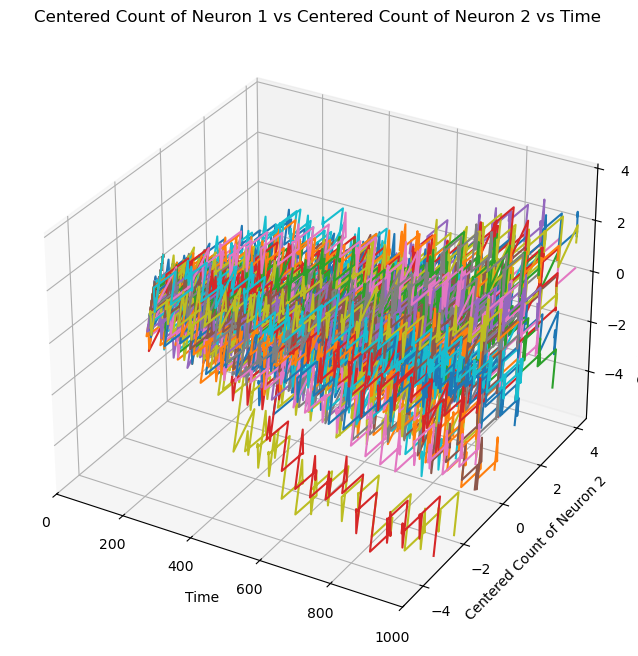

In [74]:
#plot_centered_staircase_3d(random_samples_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples= 5)
plot_centered_staircase_3d(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples)

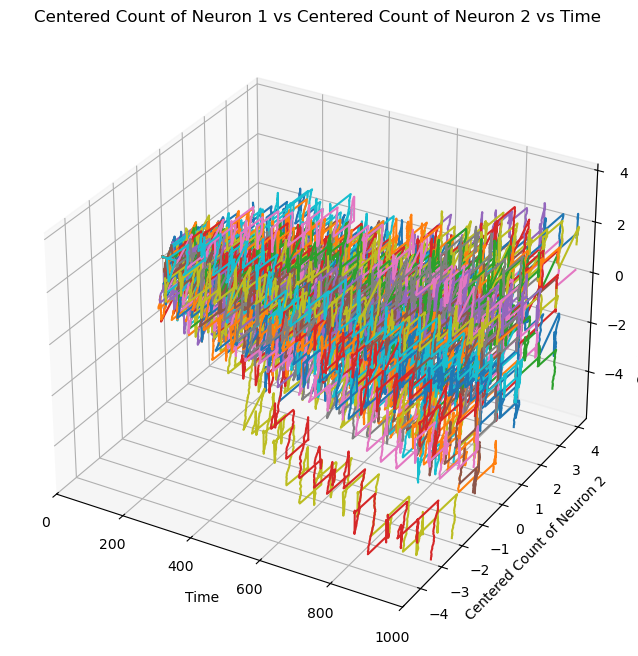

In [75]:
#plot_centered_staircase_3d(random_samples_in, empirical_mean_in, empirical_std_dev_in, num_samples= 5)
plot_centered_staircase_3d(count_in, empirical_mean_in, empirical_std_dev_in, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


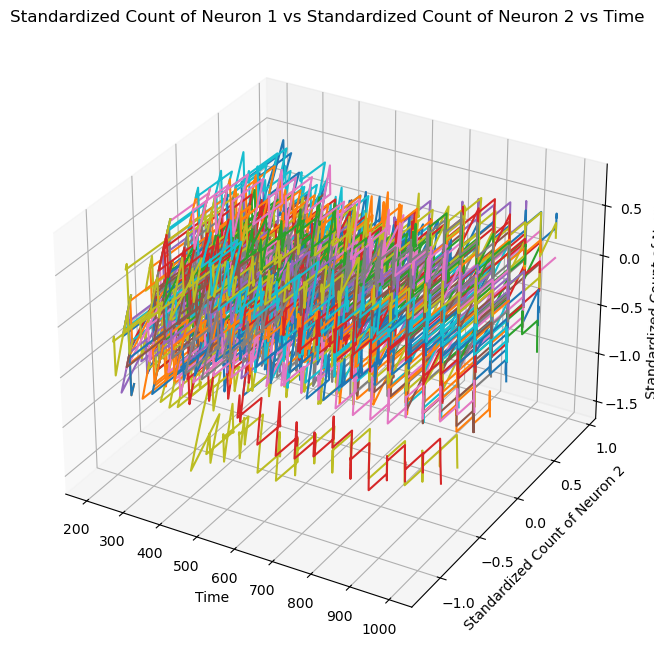

In [76]:
#plot_standardized_staircase_3d(random_samples_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0, num_samples=5)
plot_standardized_staircase_3d(count_in, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0, num_samples)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_25712\4032412390.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


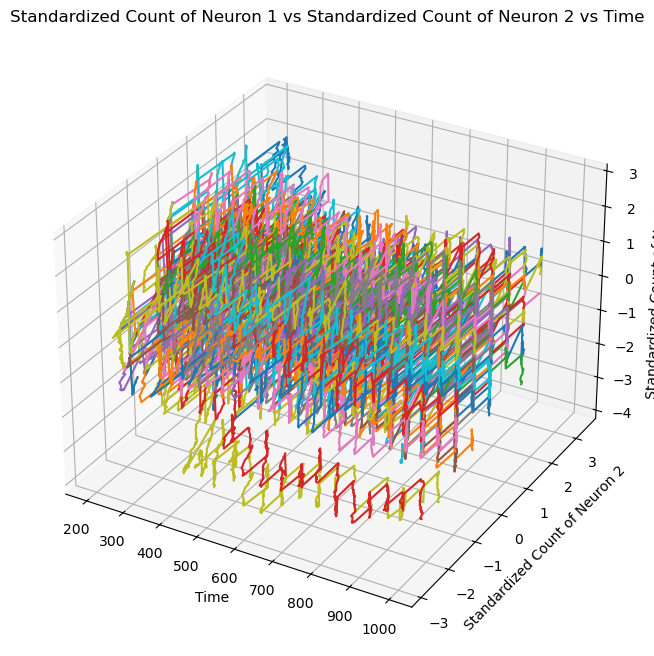

In [77]:
#plot_standardized_staircase_3d(random_samples_in, empirical_mean_in, empirical_std_dev_in, t0, num_samples=5)
plot_standardized_staircase_3d(count_in, empirical_mean_in, empirical_std_dev_in, t0, num_samples)